In [90]:
import torch
import tensordict
from tensordict import TensorDict
from transformers import AutoTokenizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [91]:
tokenizer = AutoTokenizer.from_pretrained("qwen/Qwen2.5-32B")

In [92]:
root_dir = "/mnt/blob/ckpts/DAPO-PPO/Qwen2.5-32B-GS-PR-nc/artifacts/"

# Load multiple steps and merge the data
steps = [341, 342, 343]
all_data = []

for step in steps:
    step_dir = f"{root_dir}{step}"
    td = TensorDict.load(step_dir)
    
    # Store step information
    td_with_step = {"step": step, "tensordict": td}
    all_data.append(td_with_step)
    
    print(f"Loaded step {step}")

Loaded step 341
Loaded step 342
Loaded step 342
Loaded step 343
Loaded step 343


In [162]:
td['reward'].shape

torch.Size([512])

In [163]:
# Create empty lists to store the extracted data
all_seqs_list = []
all_responses_list = []
all_prompts_list = []
all_values_list = []
all_rewards_list = []
all_response_lengths = []
all_step_info = []

# Process each step's data
for step_data in all_data:
    step = step_data["step"]
    td = step_data["tensordict"]
    
    seqs_list = []
    responses_list = []
    prompts_list = []
    values_list = []
    
    offset = 0
    response_offset = 0
    for i in range(0, len(td["full_lengths"])):
        full_length = td["full_lengths"][i]
        seq = td["seqs"][offset:offset + full_length]
        seqs_list.append(seq)
        
        response_length = td["response_lengths"][i]
        all_response_lengths.append(response_length.item())
        
        cache_length = td["cache_lengths"][i].to(torch.int64)
        prompt_length = full_length - response_length
        prompt = td["seqs"][offset:offset + prompt_length.item()]
        prompts_list.append(prompt)
        
        response = td["seqs"][offset+prompt_length.item():offset + full_length.item()]
        responses_list.append(response)
        
        offset += full_length
        
        values = td["values"][response_offset:response_offset + response_length.item()]
        values_list.append(values)

        response_offset += response_length.item()

        all_rewards = td["reward"][i]
        
        # Add step information
        all_step_info.append(step)
    
    # Extend the master lists
    all_seqs_list.extend(seqs_list)
    all_responses_list.extend(responses_list)
    all_prompts_list.extend(prompts_list)
    all_values_list.extend(values_list)
    
    print(f"Processed {len(seqs_list)} sequences from step {step}")

print(f"Total sequences processed: {len(all_seqs_list)}")

Processed 512 sequences from step 341
Processed 512 sequences from step 342
Processed 512 sequences from step 343
Total sequences processed: 1536


In [134]:
torch.cat(all_responses_list).shape

torch.Size([3994593])

In [135]:
len(all_responses_list), len(all_prompts_list), len(all_values_list), len(all_step_info)

(1536, 1536, 1536, 1536)

In [136]:
all_data[0]

{'step': 341,
 'tensordict': TensorDict(
     fields={
         cache_lengths: MemoryMappedTensor(shape=torch.Size([512]), device=cpu, dtype=torch.float32, is_shared=True),
         full_lengths: MemoryMappedTensor(shape=torch.Size([512]), device=cpu, dtype=torch.int64, is_shared=True),
         lengths: MemoryMappedTensor(shape=torch.Size([512]), device=cpu, dtype=torch.int64, is_shared=True),
         response_lengths: MemoryMappedTensor(shape=torch.Size([512]), device=cpu, dtype=torch.int64, is_shared=True),
         reward: MemoryMappedTensor(shape=torch.Size([512]), device=cpu, dtype=torch.float32, is_shared=True),
         seqs: MemoryMappedTensor(shape=torch.Size([1010616]), device=cpu, dtype=torch.int64, is_shared=True),
         values: MemoryMappedTensor(shape=torch.Size([925652]), device=cpu, dtype=torch.bfloat16, is_shared=True)},
     batch_size=torch.Size([]),
     device=cpu,
     is_shared=False)}

In [140]:
# Extract the first token value for each sequence
first_token_values = []
for value_tensor in all_values_list:
    if len(value_tensor) > 0:
        first_token_values.append(float(value_tensor[0]))
    else:
        first_token_values.append(np.nan)

# Create a DataFrame for analysis
correlation_df = pd.DataFrame({
    'step': all_step_info,
    'first_token_value': first_token_values,
    'response_length': all_response_lengths
})

# Remove any NaN values
correlation_df = correlation_df.dropna()

# Print basic statistics
print("Descriptive statistics for first token values:")
print(correlation_df['first_token_value'].describe())
print("\nDescriptive statistics for response lengths:")
print(correlation_df['response_length'].describe())

Descriptive statistics for first token values:
count    1536.000000
mean        0.062488
std         0.551409
min        -1.164062
25%        -0.504883
50%         0.230469
75%         0.527344
max         0.964844
Name: first_token_value, dtype: float64

Descriptive statistics for response lengths:
count     1536.000000
mean      2600.646484
std       2532.904816
min        327.000000
25%       1085.750000
50%       1712.000000
75%       2894.250000
max      12288.000000
Name: response_length, dtype: float64


In [141]:
# Calculate the correlation coefficient
correlation = correlation_df['first_token_value'].corr(correlation_df['response_length'])
print(f"Pearson correlation coefficient (overall): {correlation:.4f}")

# Calculate correlation by step
step_correlations = correlation_df.groupby('step').apply(
    lambda x: x['first_token_value'].corr(x['response_length'])
)
print("\nCorrelation by step:")
for step, corr in step_correlations.items():
    print(f"Step {step}: {corr:.4f}")

Pearson correlation coefficient (overall): -0.3173

Correlation by step:
Step 341: -0.3593
Step 342: -0.3054
Step 343: -0.2914


/tmp/ipykernel_85954/907337669.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  step_correlations = correlation_df.groupby('step').apply(


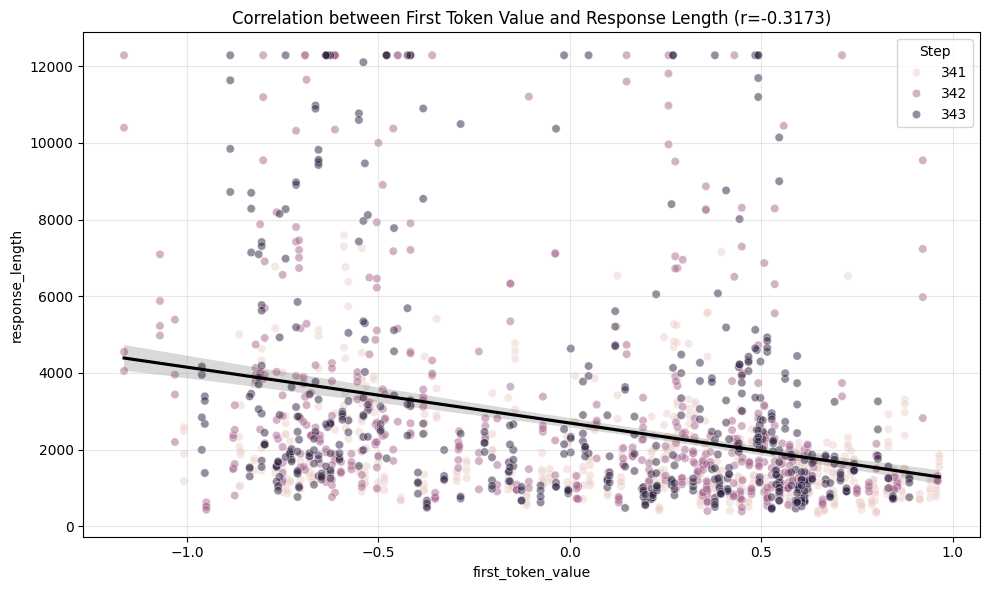

In [142]:
# Plot the overall relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='first_token_value', y='response_length', 
                hue='step', data=correlation_df, alpha=0.5)
plt.title(f'Correlation between First Token Value and Response Length (r={correlation:.4f})')
plt.xlabel('First Token Value')
plt.ylabel('Response Length')
plt.grid(True, alpha=0.3)

# Add a regression line
sns.regplot(x='first_token_value', y='response_length', 
            data=correlation_df, scatter=False, line_kws={'color': 'black'})

plt.legend(title='Step')
plt.tight_layout()
plt.show()

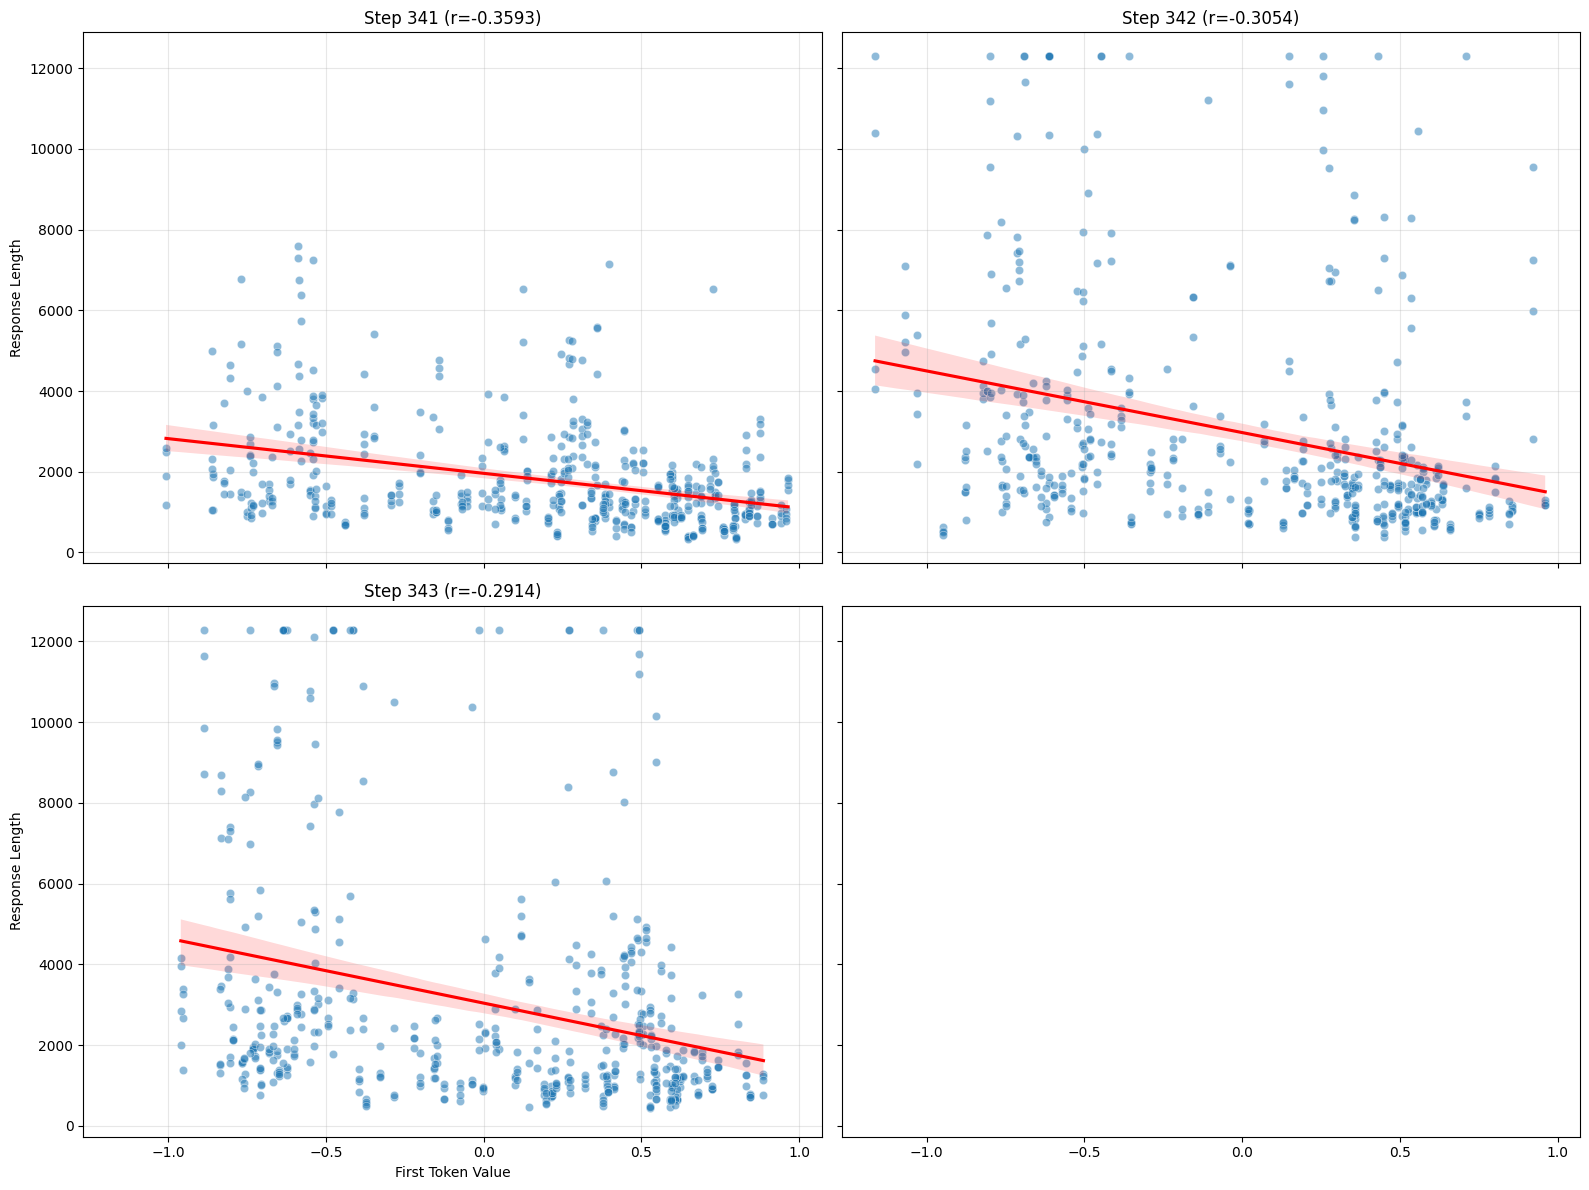

In [143]:
# Create a figure with multiple subplots for each step
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, step in enumerate(steps):
    step_data = correlation_df[correlation_df['step'] == step]
    step_corr = step_data['first_token_value'].corr(step_data['response_length'])
    
    sns.scatterplot(x='first_token_value', y='response_length', 
                   data=step_data, alpha=0.5, ax=axes[i])
    
    sns.regplot(x='first_token_value', y='response_length', 
               data=step_data, scatter=False, 
               line_kws={'color': 'red'}, ax=axes[i])
    
    axes[i].set_title(f'Step {step} (r={step_corr:.4f})')
    axes[i].set_xlabel('First Token Value')
    axes[i].set_ylabel('Response Length')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Analysis by bins of first token value (all steps):
                       value_bin         mean  count          std bin_center
0  (-1.1649999999999998, -0.727]  3556.288462    156  2772.879230  -0.946000
1               (-0.727, -0.586]  3992.157895    152  3452.465935  -0.656500
2               (-0.586, -0.383]  3970.064103    156  3072.316921  -0.484500
3             (-0.383, -0.00723]  2246.782895    152  2125.322311  -0.195115
4               (-0.00723, 0.23]  2084.927632    152  1865.925071   0.111385
5                  (0.23, 0.359]  2738.500000    160  2513.087549   0.294500
6                 (0.359, 0.484]  2282.581081    148  2184.992436   0.421500
7                 (0.484, 0.574]  2270.868750    160  2274.183636   0.529000
8                 (0.574, 0.691]  1256.052632    152   623.171867   0.632500
9                 (0.691, 0.965]  1520.358108    148  1490.964159   0.828000


/tmp/ipykernel_85954/2853157467.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_analysis = correlation_df.groupby(['value_bin'])['response_length'].agg(['mean', 'count', 'std']).reset_index()


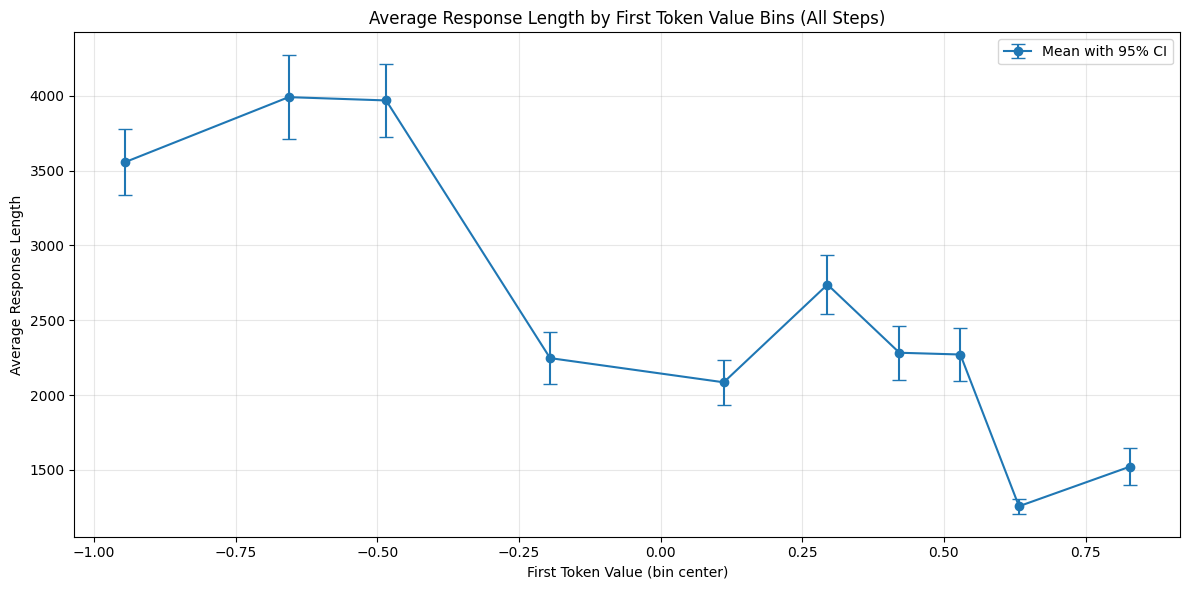

In [144]:
# Group data into bins based on first token values for a clearer view
# Create 10 bins across all data
correlation_df['value_bin'] = pd.qcut(correlation_df['first_token_value'], 10, duplicates='drop')

# Calculate average response length for each bin
bin_analysis = correlation_df.groupby(['value_bin'])['response_length'].agg(['mean', 'count', 'std']).reset_index()
bin_analysis['bin_center'] = bin_analysis['value_bin'].apply(lambda x: x.mid)

# Sort by bin center
bin_analysis = bin_analysis.sort_values('bin_center')

# Display the binned analysis
print("\nAnalysis by bins of first token value (all steps):")
print(bin_analysis)

# Plot the binned relationship
plt.figure(figsize=(12, 6))

# Plot with error bars
plt.errorbar(bin_analysis['bin_center'], bin_analysis['mean'], 
             yerr=bin_analysis['std']/np.sqrt(bin_analysis['count']), 
             fmt='o-', capsize=5, label='Mean with 95% CI')

plt.title('Average Response Length by First Token Value Bins (All Steps)')
plt.xlabel('First Token Value (bin center)')
plt.ylabel('Average Response Length')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Distribution Analysis

Let's also look at the distributions of both variables to better understand their patterns.

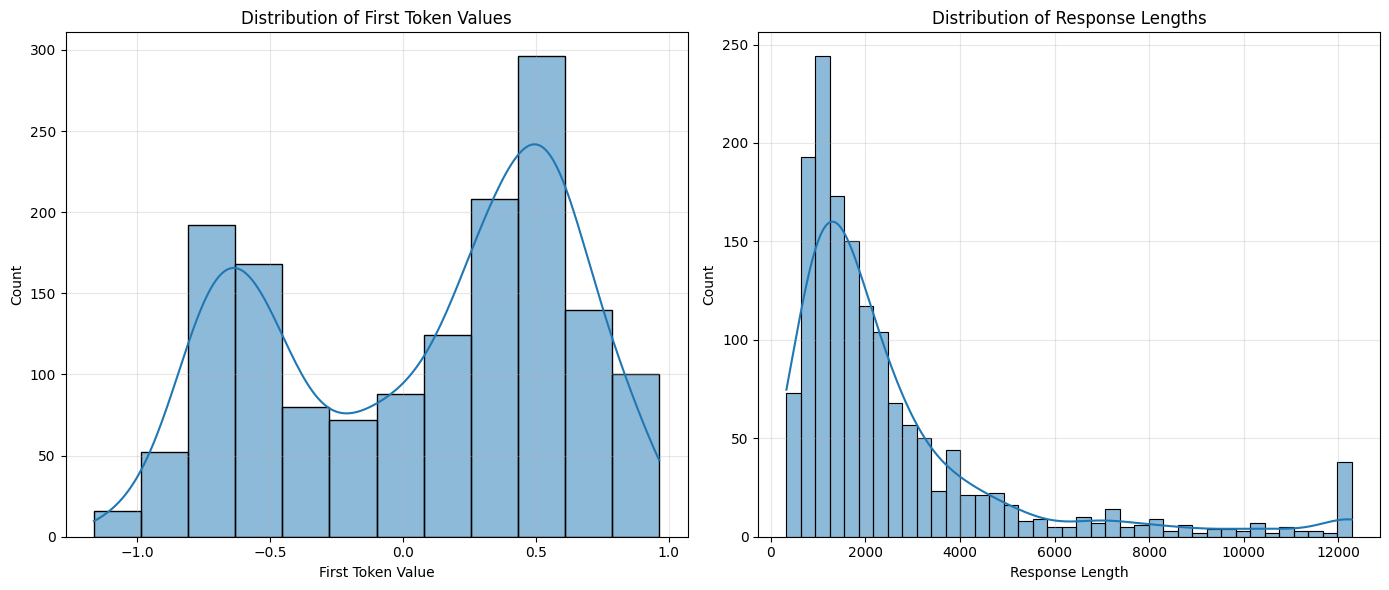

In [145]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot histogram of first token values
sns.histplot(correlation_df['first_token_value'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of First Token Values')
axes[0].set_xlabel('First Token Value')
axes[0].grid(True, alpha=0.3)

# Plot histogram of response lengths
sns.histplot(correlation_df['response_length'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Response Lengths')
axes[1].set_xlabel('Response Length')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [146]:
# Checking for outliers and their impact on correlation
# Define a function to compute correlation with different percentiles of data
def compute_correlation_without_extremes(df, column1, column2, lower_percentile, upper_percentile):
    lower_bound = df[column1].quantile(lower_percentile)
    upper_bound = df[column1].quantile(upper_percentile)
    filtered_df = df[(df[column1] >= lower_bound) & (df[column1] <= upper_bound)]
    return filtered_df[column1].corr(filtered_df[column2])

# Calculate correlation excluding outliers at different levels
percentiles = [(0, 1), (0.01, 0.99), (0.05, 0.95), (0.1, 0.9)]
results = []

for lower, upper in percentiles:
    # Overall correlation
    overall_corr = compute_correlation_without_extremes(
        correlation_df, 'first_token_value', 'response_length', lower, upper)
    
    # Step-wise correlations
    step_correlations = {}
    for step in steps:
        step_data = correlation_df[correlation_df['step'] == step]
        step_corr = compute_correlation_without_extremes(
            step_data, 'first_token_value', 'response_length', lower, upper)
        step_correlations[f'step_{step}'] = step_corr
    
    result = {
        'percentile_range': f'{lower*100}%-{upper*100}%',
        'data_included': f'{upper-lower:.2%}',
        'overall_correlation': overall_corr
    }
    result.update(step_correlations)
    results.append(result)

# Display results
correlation_robustness = pd.DataFrame(results)
print("\nCorrelation robustness to outliers:")
print(correlation_robustness)


Correlation robustness to outliers:
  percentile_range data_included  overall_correlation  step_341  step_342  \
0          0%-100%       100.00%            -0.317297 -0.359307 -0.305428   
1       1.0%-99.0%        98.00%            -0.302838 -0.366026 -0.281959   
2       5.0%-95.0%        90.00%            -0.297816 -0.352612 -0.314081   
3      10.0%-90.0%        80.00%            -0.290021 -0.398455 -0.276091   

   step_343  
0 -0.291361  
1 -0.289426  
2 -0.242617  
3 -0.221381  


# Analyzing Correlation with Multiple Tokens

Since the first token showed moderate but decreasing correlation across steps, let's examine if using multiple tokens (average of first 10 tokens) provides a more consistent predictor for response length.

In [147]:
# Extract the first 10 token values (or as many as available) for each sequence
first_token_values = []  # Keep this for comparison
first_10_avg_values = []
first_5_avg_values = []
first_3_avg_values = []

for value_tensor in all_values_list:
    if len(value_tensor) > 0:
        # First token value
        first_token_values.append(float(value_tensor[0]))
        
        # First 3 tokens average
        first_3 = value_tensor[:min(3, len(value_tensor))]
        first_3_avg_values.append(float(first_3.mean()))
        
        # First 5 tokens average
        first_5 = value_tensor[:min(5, len(value_tensor))]
        first_5_avg_values.append(float(first_5.mean()))
        
        # First 10 tokens average
        first_10 = value_tensor[:min(10, len(value_tensor))]
        first_10_avg_values.append(float(first_10.mean()))
    else:
        first_token_values.append(np.nan)
        first_3_avg_values.append(np.nan)
        first_5_avg_values.append(np.nan)
        first_10_avg_values.append(np.nan)

# Create a DataFrame for analysis with multiple token metrics
multi_token_df = pd.DataFrame({
    'step': all_step_info,
    'first_token_value': first_token_values,
    'first_3_avg': first_3_avg_values,
    'first_5_avg': first_5_avg_values,
    'first_10_avg': first_10_avg_values,
    'response_length': all_response_lengths
})

# Remove any NaN values
multi_token_df = multi_token_df.dropna()

# Print basic statistics for multi-token metrics
print("Descriptive statistics for first token values:")
print(multi_token_df['first_token_value'].describe())
print("\nDescriptive statistics for average of first 3 tokens:")
print(multi_token_df['first_3_avg'].describe())
print("\nDescriptive statistics for average of first 5 tokens:")
print(multi_token_df['first_5_avg'].describe())
print("\nDescriptive statistics for average of first 10 tokens:")
print(multi_token_df['first_10_avg'].describe())
print("\nDescriptive statistics for response lengths:")
print(multi_token_df['response_length'].describe())

Descriptive statistics for first token values:
count    1536.000000
mean        0.062488
std         0.551409
min        -1.164062
25%        -0.504883
50%         0.230469
75%         0.527344
max         0.964844
Name: first_token_value, dtype: float64

Descriptive statistics for average of first 3 tokens:
count    1536.000000
mean        0.022543
std         0.567679
min        -1.195312
25%        -0.564453
50%         0.218750
75%         0.503906
max         0.875000
Name: first_3_avg, dtype: float64

Descriptive statistics for average of first 5 tokens:
count    1536.000000
mean        0.000569
std         0.564305
min        -1.195312
25%        -0.585938
50%         0.185059
75%         0.480469
max         0.851562
Name: first_5_avg, dtype: float64

Descriptive statistics for average of first 10 tokens:
count    1536.000000
mean       -0.016561
std         0.584024
min        -1.203125
25%        -0.613281
50%         0.163086
75%         0.482422
max         0.859375
Name: f

In [148]:
# Calculate the correlation coefficients for different metrics
correlation_metrics = {
    'first_token': multi_token_df['first_token_value'].corr(multi_token_df['response_length']),
    'first_3_avg': multi_token_df['first_3_avg'].corr(multi_token_df['response_length']),
    'first_5_avg': multi_token_df['first_5_avg'].corr(multi_token_df['response_length']),
    'first_10_avg': multi_token_df['first_10_avg'].corr(multi_token_df['response_length'])
}

print("Overall correlation coefficients:")
for metric, corr in correlation_metrics.items():
    print(f"{metric}: {corr:.4f}")
    
# Calculate correlation by step for each metric
print("\nCorrelation by step:")
for step in steps:
    step_data = multi_token_df[multi_token_df['step'] == step]
    print(f"\nStep {step}:")
    for col in ['first_token_value', 'first_3_avg', 'first_5_avg', 'first_10_avg']:
        corr = step_data[col].corr(step_data['response_length'])
        print(f"{col}: {corr:.4f}")

Overall correlation coefficients:
first_token: -0.3173
first_3_avg: -0.3359
first_5_avg: -0.3396
first_10_avg: -0.3424

Correlation by step:

Step 341:
first_token_value: -0.3593
first_3_avg: -0.3763
first_5_avg: -0.3797
first_10_avg: -0.3873

Step 342:
first_token_value: -0.3054
first_3_avg: -0.3297
first_5_avg: -0.3323
first_10_avg: -0.3343

Step 343:
first_token_value: -0.2914
first_3_avg: -0.3079
first_5_avg: -0.3129
first_10_avg: -0.3160


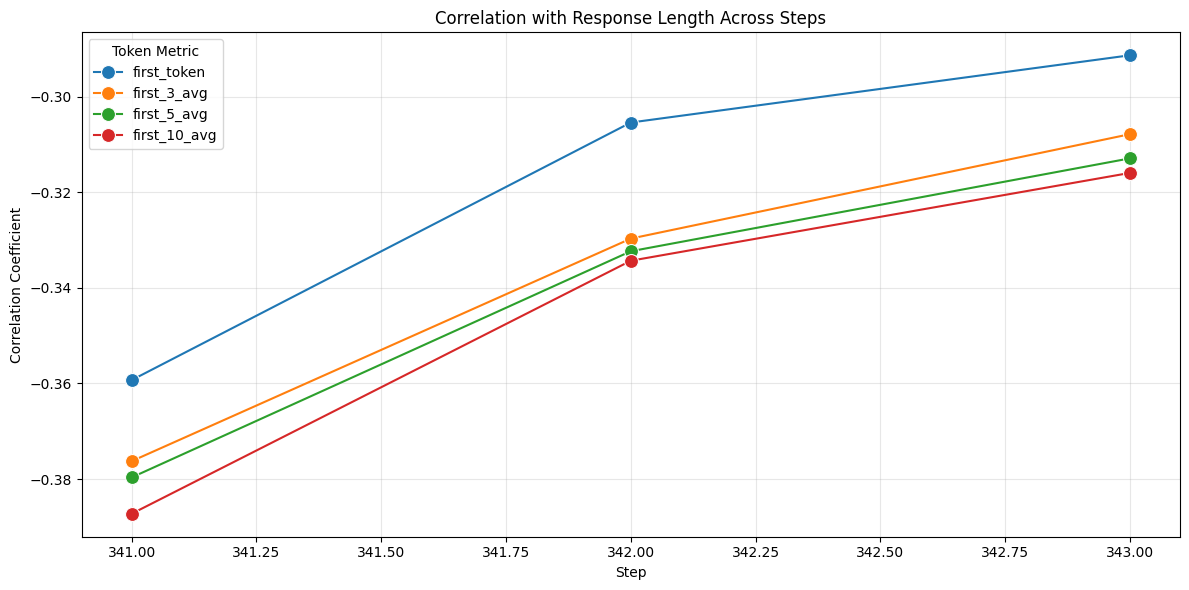

In [149]:
# Create a figure to compare the correlations across steps
step_correlations = []

for step in steps:
    step_data = multi_token_df[multi_token_df['step'] == step]
    step_corr = {
        'step': step,
        'first_token': step_data['first_token_value'].corr(step_data['response_length']),
        'first_3_avg': step_data['first_3_avg'].corr(step_data['response_length']),
        'first_5_avg': step_data['first_5_avg'].corr(step_data['response_length']),
        'first_10_avg': step_data['first_10_avg'].corr(step_data['response_length'])
    }
    step_correlations.append(step_corr)

step_corr_df = pd.DataFrame(step_correlations)

# Melt the dataframe for easier plotting
step_corr_melted = pd.melt(step_corr_df, id_vars=['step'], 
                           value_vars=['first_token', 'first_3_avg', 'first_5_avg', 'first_10_avg'],
                           var_name='metric', value_name='correlation')

# Plot the correlations across steps
plt.figure(figsize=(12, 6))
sns.lineplot(data=step_corr_melted, x='step', y='correlation', hue='metric', marker='o', markersize=10)
plt.title('Correlation with Response Length Across Steps')
plt.xlabel('Step')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.legend(title='Token Metric')
plt.tight_layout()
plt.show()

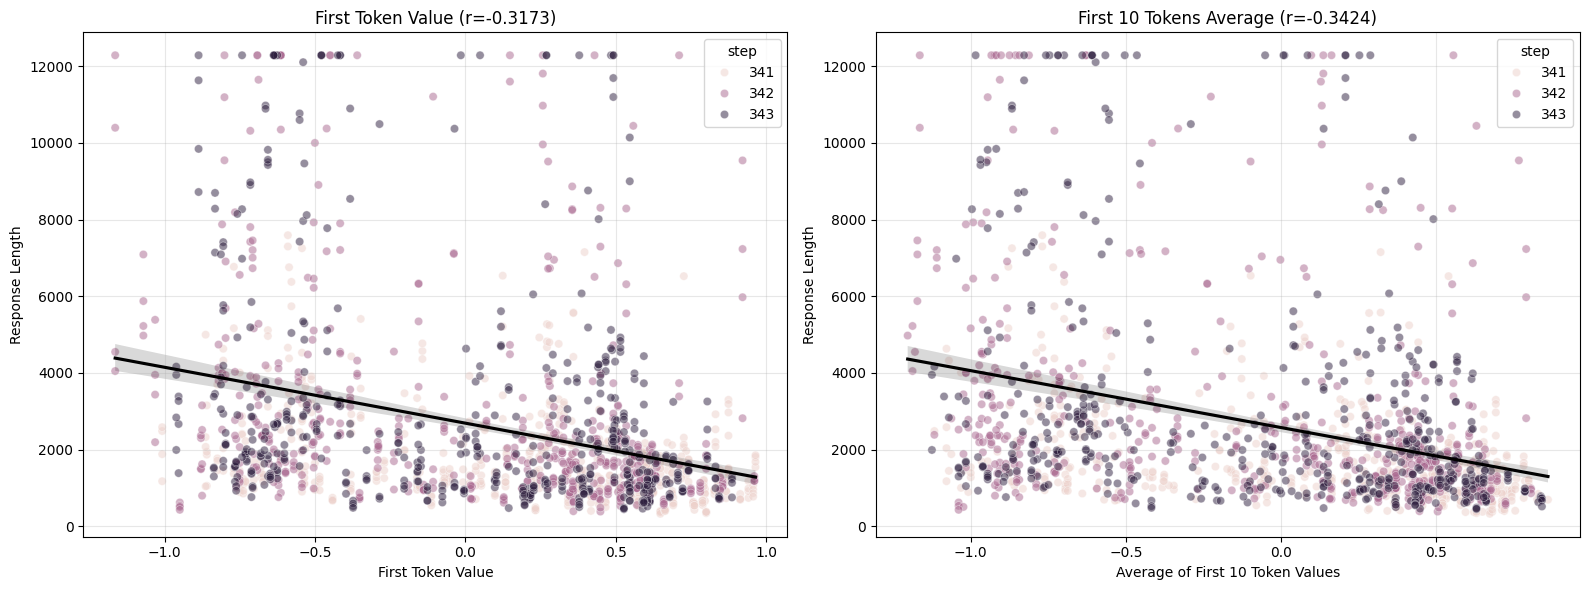

In [150]:
# Compare scatter plots for first token vs first 10 tokens average
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First token value
sns.scatterplot(x='first_token_value', y='response_length', 
                hue='step', data=multi_token_df, alpha=0.5, ax=axes[0])
sns.regplot(x='first_token_value', y='response_length', 
            data=multi_token_df, scatter=False, 
            line_kws={'color': 'black'}, ax=axes[0])
axes[0].set_title(f'First Token Value (r={correlation_metrics["first_token"]:.4f})')
axes[0].set_xlabel('First Token Value')
axes[0].set_ylabel('Response Length')
axes[0].grid(True, alpha=0.3)

# First 10 tokens average
sns.scatterplot(x='first_10_avg', y='response_length', 
                hue='step', data=multi_token_df, alpha=0.5, ax=axes[1])
sns.regplot(x='first_10_avg', y='response_length', 
            data=multi_token_df, scatter=False, 
            line_kws={'color': 'black'}, ax=axes[1])
axes[1].set_title(f'First 10 Tokens Average (r={correlation_metrics["first_10_avg"]:.4f})')
axes[1].set_xlabel('Average of First 10 Token Values')
axes[1].set_ylabel('Response Length')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

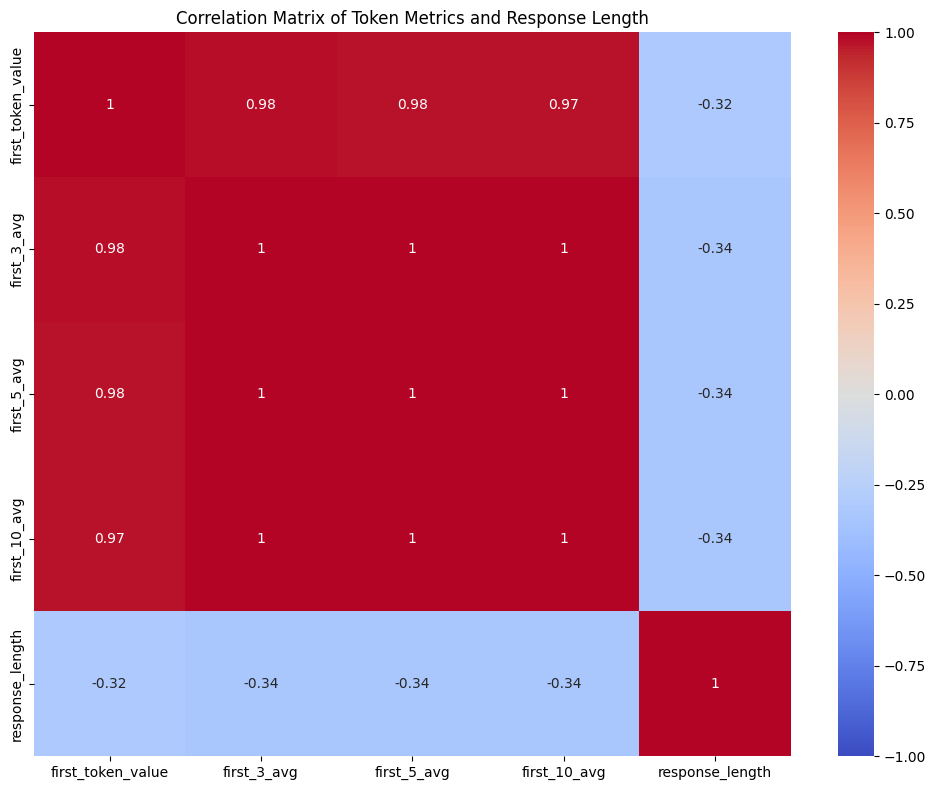

In [151]:
# Create heatmap to visualize correlation matrix
correlation_matrix = multi_token_df[['first_token_value', 'first_3_avg', 'first_5_avg', 
                                    'first_10_avg', 'response_length']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Token Metrics and Response Length')
plt.tight_layout()
plt.show()

Analysis by bins of first 10 tokens average (all steps):
        value_bin_10         mean  count          std bin_center
0   (-1.204, -0.887]  3892.006452    155  3016.901813    -1.0455
1   (-0.887, -0.711]  3708.500000    158  3120.017899    -0.7990
2   (-0.711, -0.488]  3644.651007    149  3117.483317    -0.5995
3  (-0.488, -0.0654]  2626.535948    153  2338.219445    -0.2767
4   (-0.0654, 0.163]  2912.318182    154  2921.262058     0.0488
5     (0.163, 0.336]  2600.529412    153  2529.267431     0.2495
6      (0.336, 0.44]  1950.137255    153  1421.572027     0.3880
7      (0.44, 0.531]  1617.445860    157  1218.614532     0.4855
8     (0.531, 0.643]  1826.060000    150  1689.131651     0.5870
9     (0.643, 0.859]  1219.993506    154  1074.533992     0.7510


/tmp/ipykernel_85954/3376707667.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_analysis_10 = multi_token_df.groupby(['value_bin_10'])['response_length'].agg(['mean', 'count', 'std']).reset_index()


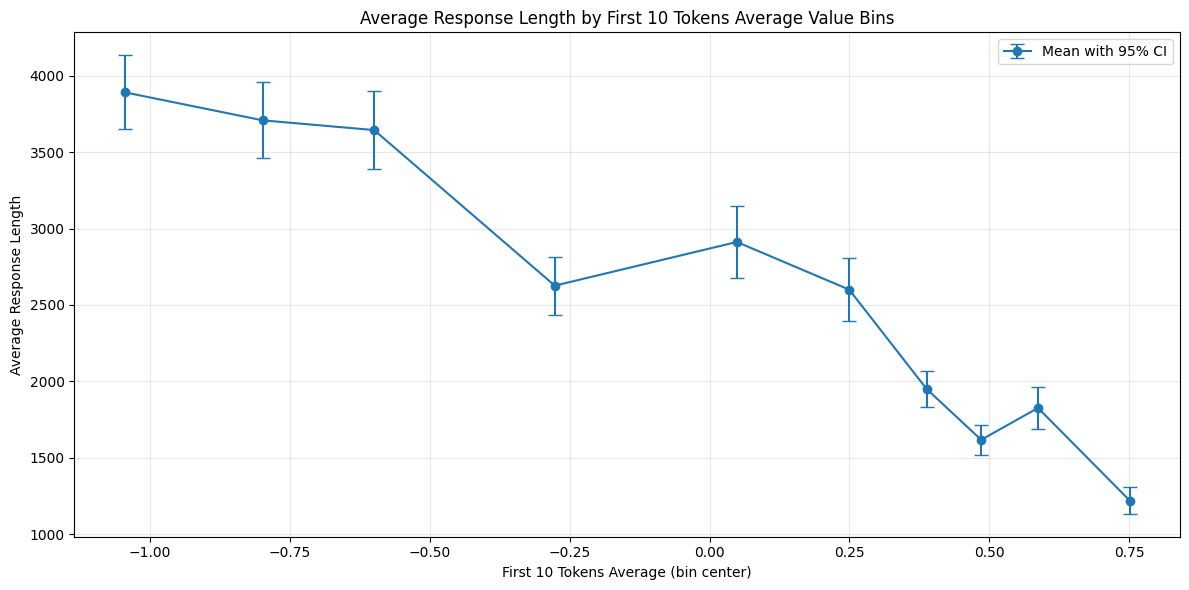

In [152]:
# Bin analysis for first 10 tokens average
multi_token_df['value_bin_10'] = pd.qcut(multi_token_df['first_10_avg'], 10, duplicates='drop')

# Calculate bin statistics
bin_analysis_10 = multi_token_df.groupby(['value_bin_10'])['response_length'].agg(['mean', 'count', 'std']).reset_index()
bin_analysis_10['bin_center'] = bin_analysis_10['value_bin_10'].apply(lambda x: x.mid)
bin_analysis_10 = bin_analysis_10.sort_values('bin_center')

print("Analysis by bins of first 10 tokens average (all steps):")
print(bin_analysis_10)

# Plot the binned relationship
plt.figure(figsize=(12, 6))
plt.errorbar(bin_analysis_10['bin_center'], bin_analysis_10['mean'], 
             yerr=bin_analysis_10['std']/np.sqrt(bin_analysis_10['count']), 
             fmt='o-', capsize=5, label='Mean with 95% CI')
plt.title('Average Response Length by First 10 Tokens Average Value Bins')
plt.xlabel('First 10 Tokens Average (bin center)')
plt.ylabel('Average Response Length')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Analysis of Token-by-Token Correlation

Let's also examine how the correlation changes for individual token positions across the response.

In [153]:
# Analyze correlation for individual token positions (1st, 2nd, 3rd, etc.)
max_tokens_to_analyze = 20  # Analyze up to the first 20 tokens
position_corr = []

for pos in range(max_tokens_to_analyze):
    token_values = []
    response_lengths = []
    steps = []
    
    for i, values in enumerate(all_values_list):
        if len(values) > pos:  # Check if this position exists
            token_values.append(float(values[pos]))
            response_lengths.append(all_response_lengths[i])
            steps.append(all_step_info[i])
    
    # Create a DataFrame for this position
    pos_df = pd.DataFrame({
        'token_value': token_values,
        'response_length': response_lengths,
        'step': steps
    })
    
    # Calculate overall correlation
    overall_corr = pos_df['token_value'].corr(pos_df['response_length'])
    
    # Calculate correlation by step
    step_corrs = {}
    for step in pd.unique(pos_df['step']):
        step_data = pos_df[pos_df['step'] == step]
        step_corrs[step] = step_data['token_value'].corr(step_data['response_length'])
    
    position_corr.append({
        'position': pos + 1,  # 1-indexed for clarity
        'overall_corr': overall_corr,
        **{f'step_{step}': corr for step, corr in step_corrs.items()}
    })

position_corr_df = pd.DataFrame(position_corr)
print("Correlation by token position:")
print(position_corr_df)

Correlation by token position:
    position  overall_corr  step_341  step_342  step_343
0          1     -0.317297 -0.359307 -0.305428 -0.291361
1          2     -0.335765 -0.386558 -0.324655 -0.312317
2          3     -0.341382 -0.370390 -0.343111 -0.309638
3          4     -0.352646 -0.388484 -0.344779 -0.327207
4          5     -0.327574 -0.368219 -0.318905 -0.303984
5          6     -0.333935 -0.390922 -0.324543 -0.307705
6          7     -0.337637 -0.373936 -0.332796 -0.315370
7          8     -0.333343 -0.378547 -0.332331 -0.299716
8          9     -0.358213 -0.407859 -0.357911 -0.325569
9         10     -0.341636 -0.393803 -0.315280 -0.326132
10        11     -0.336003 -0.409356 -0.318192 -0.303632
11        12     -0.328937 -0.377688 -0.315693 -0.310544
12        13     -0.333505 -0.393016 -0.325737 -0.303768
13        14     -0.343719 -0.400108 -0.335603 -0.315643
14        15     -0.333230 -0.395159 -0.331675 -0.299751
15        16     -0.332890 -0.401930 -0.329389 -0.291106


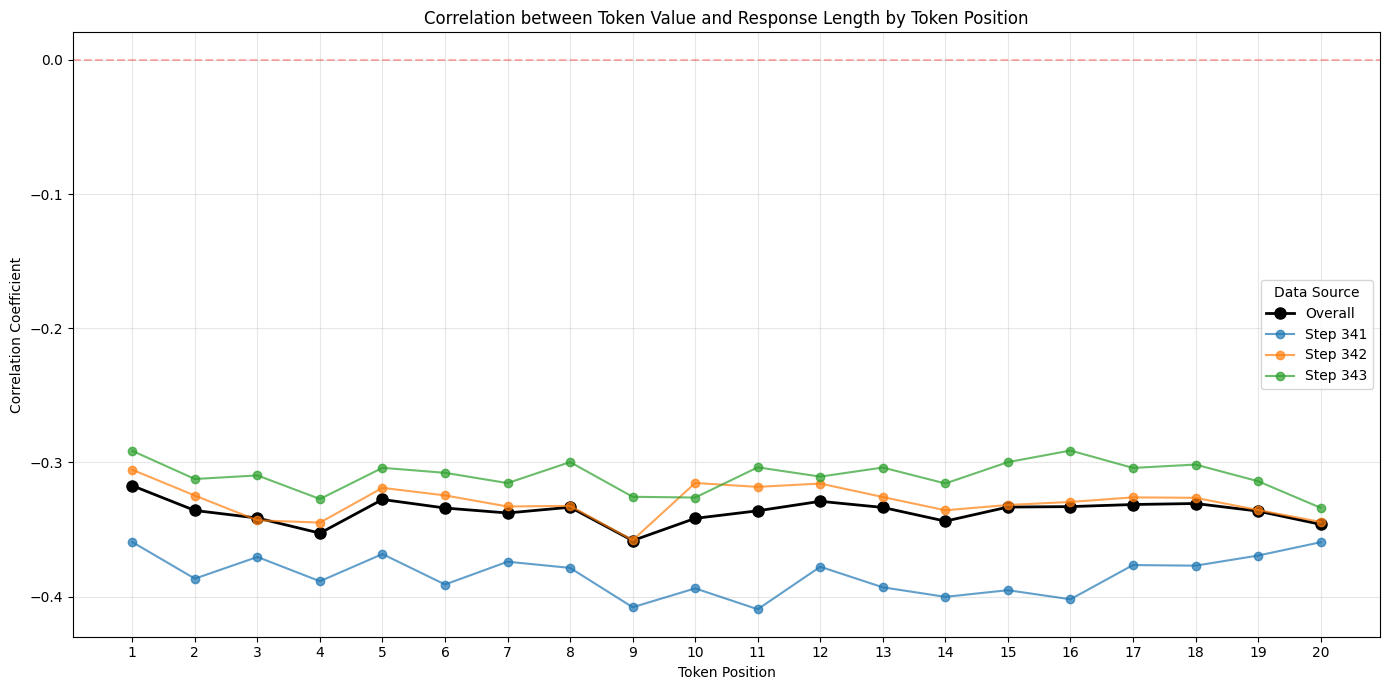

In [154]:
# Plot the correlations by token position
plt.figure(figsize=(14, 7))

# Plot overall correlation
plt.plot(position_corr_df['position'], position_corr_df['overall_corr'], 
         'o-', linewidth=2, label='Overall', color='black', markersize=8)

# Plot step-wise correlations
step_columns = [col for col in position_corr_df.columns if col.startswith('step_')]
for col in step_columns:
    step = col.split('_')[1]
    plt.plot(position_corr_df['position'], position_corr_df[col], 
             'o-', linewidth=1.5, label=f'Step {step}', alpha=0.7)

plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.title('Correlation between Token Value and Response Length by Token Position')
plt.xlabel('Token Position')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.legend(title='Data Source')
plt.xticks(position_corr_df['position'])
plt.tight_layout()
plt.show()

# Spearman Correlation Analysis

Let's analyze the relationship using Spearman's rank correlation, which is less sensitive to outliers and can detect monotonic relationships even when they're not strictly linear.

In [155]:
# Calculate Spearman correlation for first token value and response length
spearman_corr = correlation_df['first_token_value'].corr(correlation_df['response_length'], method='spearman')
print(f"Overall Spearman correlation coefficient: {spearman_corr:.4f}")

# Calculate Spearman correlation by step
spearman_step_correlations = correlation_df.groupby('step').apply(
    lambda x: x['first_token_value'].corr(x['response_length'], method='spearman')
)
print("\nSpearman correlation by step:")
for step, corr in spearman_step_correlations.items():
    print(f"Step {step}: {corr:.4f}")

Overall Spearman correlation coefficient: -0.4023

Spearman correlation by step:
Step 341: -0.3954
Step 342: -0.4082
Step 343: -0.3506


/tmp/ipykernel_85954/2525866221.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spearman_step_correlations = correlation_df.groupby('step').apply(


In [156]:
# Calculate Spearman correlation for multi-token metrics
spearman_metrics = {
    'first_token': multi_token_df['first_token_value'].corr(multi_token_df['response_length'], method='spearman'),
    'first_3_avg': multi_token_df['first_3_avg'].corr(multi_token_df['response_length'], method='spearman'),
    'first_5_avg': multi_token_df['first_5_avg'].corr(multi_token_df['response_length'], method='spearman'),
    'first_10_avg': multi_token_df['first_10_avg'].corr(multi_token_df['response_length'], method='spearman')
}

print("Overall Spearman correlation coefficients:")
for metric, corr in spearman_metrics.items():
    print(f"{metric}: {corr:.4f}")

# Calculate Spearman correlation by step for each metric
print("\nSpearman correlation by step:")
for step in steps:
    step_data = multi_token_df[multi_token_df['step'] == step]
    print(f"\nStep {step}:")
    for col in ['first_token_value', 'first_3_avg', 'first_5_avg', 'first_10_avg']:
        corr = step_data[col].corr(step_data['response_length'], method='spearman')
        print(f"{col}: {corr:.4f}")

Overall Spearman correlation coefficients:
first_token: -0.4023
first_3_avg: -0.4273
first_5_avg: -0.4323
first_10_avg: -0.4418

Spearman correlation by step:

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_va

first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
first_5_avg: -0.4274
first_10_avg: -0.4360

Step 341:
first_token_value: -0.3954
first_3_avg: -0.4240
f

Correlation coefficient comparison (Pearson vs Spearman):
         Metric   Pearson  Spearman
0   first_token -0.317297 -0.402258
1   first_3_avg -0.335887 -0.427340
2   first_5_avg -0.339607 -0.432320
3  first_10_avg -0.342418 -0.441807


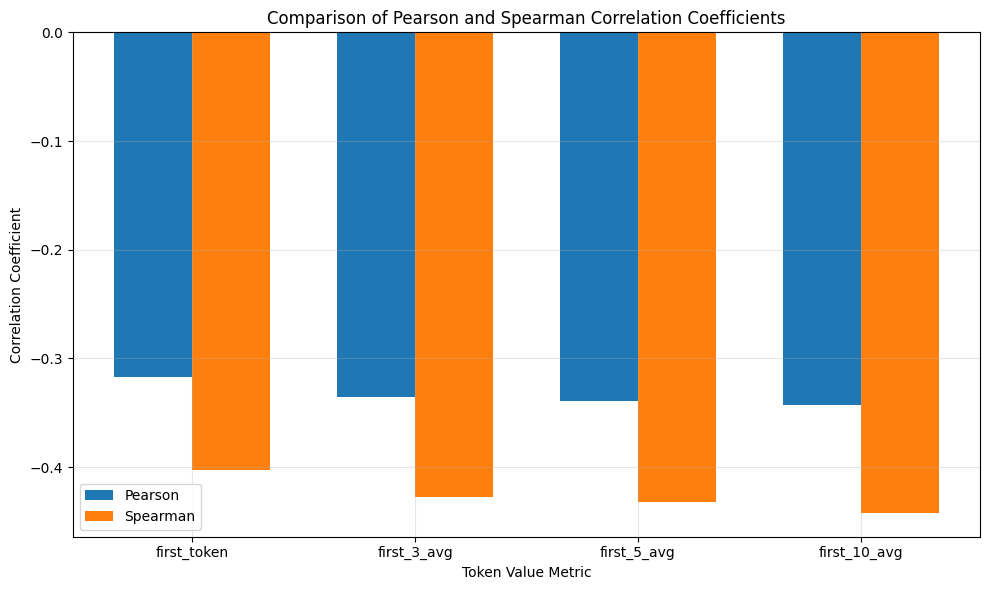

In [157]:
# Create a comparison of Pearson vs Spearman correlations
metric_names = ['first_token', 'first_3_avg', 'first_5_avg', 'first_10_avg']
correlation_comparison = pd.DataFrame({
    'Metric': metric_names,
    'Pearson': [correlation_metrics[m] for m in metric_names],
    'Spearman': [spearman_metrics[m] for m in metric_names]
})

print("Correlation coefficient comparison (Pearson vs Spearman):")
print(correlation_comparison)

# Plot comparison
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(metric_names))

plt.bar(x - bar_width/2, correlation_comparison['Pearson'], bar_width, label='Pearson')
plt.bar(x + bar_width/2, correlation_comparison['Spearman'], bar_width, label='Spearman')

plt.xlabel('Token Value Metric')
plt.ylabel('Correlation Coefficient')
plt.title('Comparison of Pearson and Spearman Correlation Coefficients')
plt.xticks(x, metric_names)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [158]:
# Analyze Spearman correlation for individual token positions
position_spearman_corr = []

for pos in range(max_tokens_to_analyze):
    token_values = []
    response_lengths = []
    steps = []
    
    for i, values in enumerate(all_values_list):
        if len(values) > pos:  # Check if this position exists
            token_values.append(float(values[pos]))
            response_lengths.append(all_response_lengths[i])
            steps.append(all_step_info[i])
    
    # Create a DataFrame for this position
    pos_df = pd.DataFrame({
        'token_value': token_values,
        'response_length': response_lengths,
        'step': steps
    })
    
    # Calculate overall Spearman correlation
    overall_corr = pos_df['token_value'].corr(pos_df['response_length'], method='spearman')
    
    # Calculate Spearman correlation by step
    step_corrs = {}
    for step in pd.unique(pos_df['step']):
        step_data = pos_df[pos_df['step'] == step]
        step_corrs[step] = step_data['token_value'].corr(step_data['response_length'], method='spearman')
    
    position_spearman_corr.append({
        'position': pos + 1,  # 1-indexed for clarity
        'overall_corr': overall_corr,
        **{f'step_{step}': corr for step, corr in step_corrs.items()}
    })

position_spearman_df = pd.DataFrame(position_spearman_corr)
print("Spearman correlation by token position:")
print(position_spearman_df)

Spearman correlation by token position:
    position  overall_corr  step_341  step_342  step_343
0          1     -0.402258 -0.395404 -0.408229 -0.350619
1          2     -0.431118 -0.440780 -0.428016 -0.380885
2          3     -0.431648 -0.419892 -0.438658 -0.380069
3          4     -0.444082 -0.427376 -0.444183 -0.399516
4          5     -0.417308 -0.413269 -0.407194 -0.373414
5          6     -0.435610 -0.426026 -0.426936 -0.392836
6          7     -0.438435 -0.423876 -0.445242 -0.390986
7          8     -0.424166 -0.425689 -0.429864 -0.372023
8          9     -0.457981 -0.447813 -0.462814 -0.397420
9         10     -0.433045 -0.428206 -0.410941 -0.392830
10        11     -0.432256 -0.440545 -0.409584 -0.379258
11        12     -0.415687 -0.396071 -0.408967 -0.380337
12        13     -0.420028 -0.414442 -0.424335 -0.363842
13        14     -0.430422 -0.418246 -0.436920 -0.386683
14        15     -0.419555 -0.411288 -0.439124 -0.352274
15        16     -0.421978 -0.420754 -0.426877 -

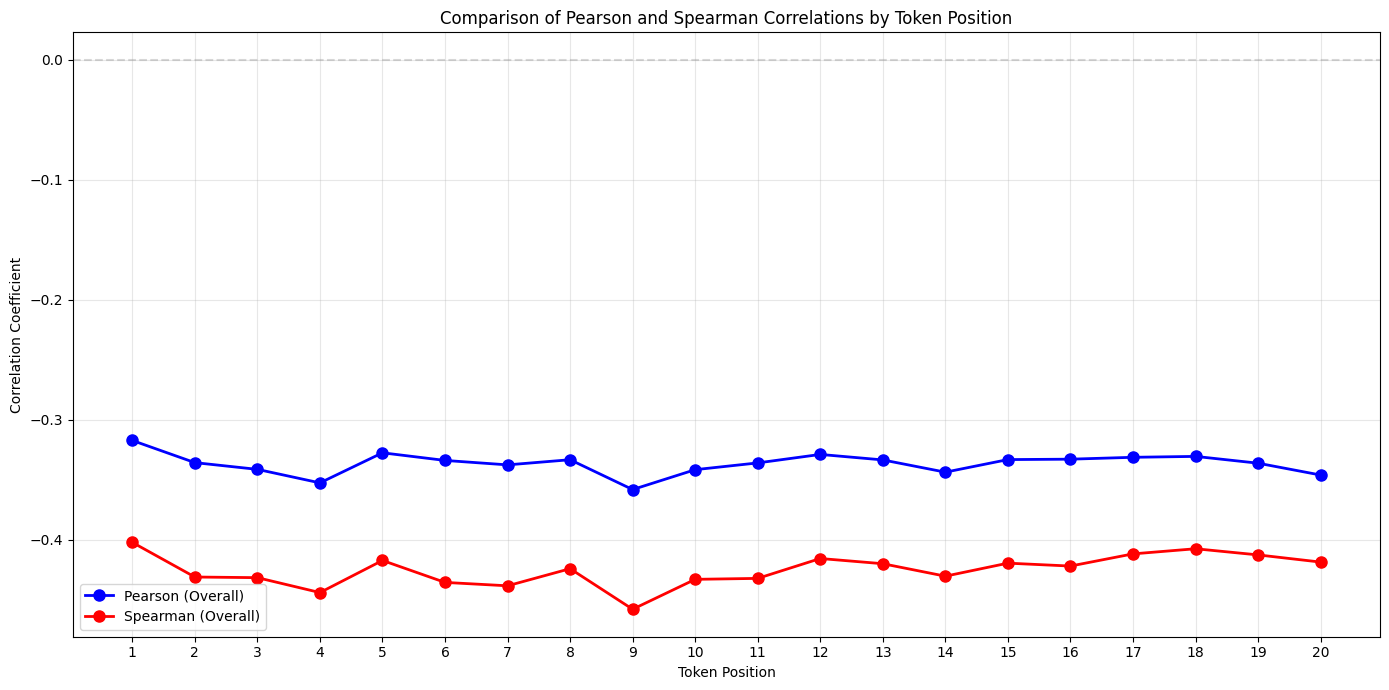

In [159]:
# Plot comparison between Pearson and Spearman correlations by token position
plt.figure(figsize=(14, 7))

# Plot overall Pearson correlation
plt.plot(position_corr_df['position'], position_corr_df['overall_corr'], 
         'o-', linewidth=2, label='Pearson (Overall)', color='blue', markersize=8)

# Plot overall Spearman correlation
plt.plot(position_spearman_df['position'], position_spearman_df['overall_corr'], 
         'o-', linewidth=2, label='Spearman (Overall)', color='red', markersize=8)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.title('Comparison of Pearson and Spearman Correlations by Token Position')
plt.xlabel('Token Position')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(position_corr_df['position'])
plt.tight_layout()
plt.show()

## Interpretation of Correlation Strength

General guidelines for interpreting correlation coefficients:

| Correlation Coefficient (absolute value) | Interpretation      |
|------------------------------------------|---------------------|
| 0.00 - 0.19                             | Very weak           |
| 0.20 - 0.39                             | Weak                |
| 0.40 - 0.59                             | Moderate            |
| 0.60 - 0.79                             | Strong              |
| 0.80 - 1.00                             | Very strong         |

Coefficient of determination (r²) indicates the proportion of variance in the dependent variable that can be explained by the independent variable.

Coefficient of determination (r²) by metric:
         Metric  Pearson_r  Pearson_r²  Spearman_r  Spearman_r²
0   first_token  -0.317297    0.100677   -0.402258     0.161811
1   first_3_avg  -0.335887    0.112820   -0.427340     0.182619
2   first_5_avg  -0.339607    0.115333   -0.432320     0.186900
3  first_10_avg  -0.342418    0.117250   -0.441807     0.195194


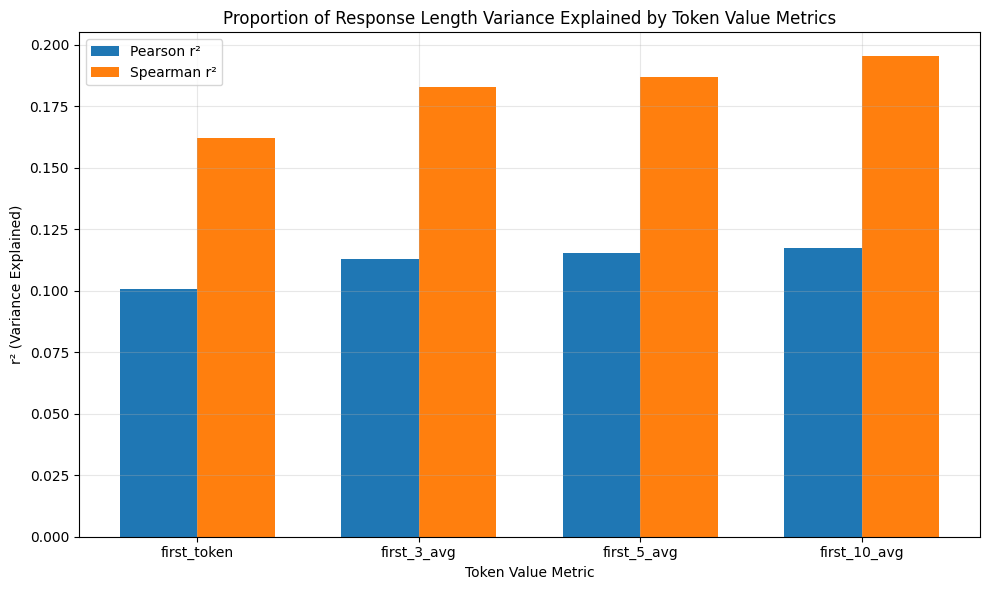

In [160]:
# Calculate coefficient of determination (r-squared) for both correlation types
r_squared_comparison = pd.DataFrame({
    'Metric': metric_names,
    'Pearson_r': [correlation_metrics[m] for m in metric_names],
    'Pearson_r²': [correlation_metrics[m]**2 for m in metric_names],
    'Spearman_r': [spearman_metrics[m] for m in metric_names],
    'Spearman_r²': [spearman_metrics[m]**2 for m in metric_names]
})

print("Coefficient of determination (r²) by metric:")
print(r_squared_comparison)

# Plot r-squared values
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(metric_names))

plt.bar(x - bar_width/2, r_squared_comparison['Pearson_r²'], bar_width, label='Pearson r²')
plt.bar(x + bar_width/2, r_squared_comparison['Spearman_r²'], bar_width, label='Spearman r²')

plt.xlabel('Token Value Metric')
plt.ylabel('r² (Variance Explained)')
plt.title('Proportion of Response Length Variance Explained by Token Value Metrics')
plt.xticks(x, metric_names)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Comprehensive Analysis of Correlation with Rewards

In this section, we'll analyze the correlation between token values and the reward data. This includes examining how the correlation varies for individual token positions and how it compares to the correlation with response length.

# Analyzing Correlation Between Token Values and Reward

Now let's examine if there's a correlation between the token values (first token and averages of first few tokens) and the reward values.

In [175]:
# Extract reward values from the tensor dictionary
rewards_list = []

# Process each step's data to extract rewards
for step_data in all_data:
    td = step_data["tensordict"]
    
    for i in range(len(td["full_lengths"])):
        # Get the reward for this sequence - it's a single value, not per token
        reward = td["reward"][i].item()  # Extract the single reward value
        
        # Add to our list
        rewards_list.append(reward)

print(f"Extracted rewards for {len(rewards_list)} sequences")

# Create a DataFrame for reward analysis
reward_df = pd.DataFrame({
    'step': all_step_info,
    'first_token_value': first_token_values,
    'first_3_avg': first_3_avg_values,
    'first_5_avg': first_5_avg_values,
    'first_10_avg': first_10_avg_values,
    'reward': rewards_list,
    'response_length': all_response_lengths
})

# Remove any NaN values
reward_df = reward_df.dropna()

# Print basic statistics for reward metrics
print("\nDescriptive statistics for rewards:")
print(reward_df['reward'].describe())

Extracted rewards for 1536 sequences

Descriptive statistics for rewards:
count    1536.000000
mean       -0.021484
std         0.153761
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: reward, dtype: float64


In [179]:
# Calculate correlation between token values and reward metrics
token_cols = ['first_token_value', 'first_3_avg', 'first_5_avg', 'first_10_avg']
reward_cols = ['reward']

# Create a correlation matrix for token values vs rewards
correlation_matrix = pd.DataFrame(index=token_cols, columns=reward_cols)
spearman_matrix = pd.DataFrame(index=token_cols, columns=reward_cols)

# Calculate Pearson correlations
for token_col in token_cols:
    for reward_col in reward_cols:
        correlation_matrix.loc[token_col, reward_col] = reward_df[token_col].corr(reward_df[reward_col])
        spearman_matrix.loc[token_col, reward_col] = reward_df[token_col].corr(reward_df[reward_col], method='spearman')

print("Pearson correlation between token values and rewards:")
print(correlation_matrix)

print("\nSpearman correlation between token values and rewards:")
print(spearman_matrix)

Pearson correlation between token values and rewards:
                     reward
first_token_value  0.089177
first_3_avg        0.096606
first_5_avg        0.099053
first_10_avg       0.098309

Spearman correlation between token values and rewards:
                     reward
first_token_value  0.085595
first_3_avg        0.099191
first_5_avg        0.101781
first_10_avg       0.100725


TypeError: Image data of dtype object cannot be converted to float

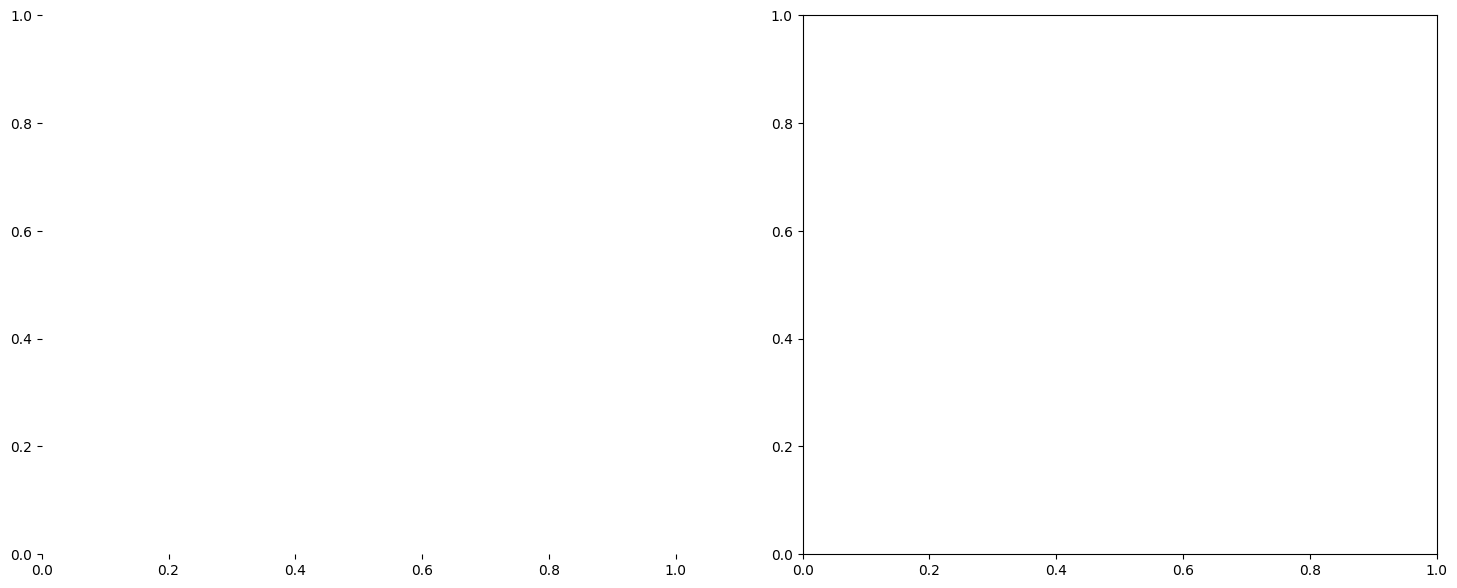

In [180]:
# Visualize the correlation matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot Pearson correlation heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, ax=axes[0])
axes[0].set_title('Pearson Correlation: Token Values vs Rewards')

# Plot Spearman correlation heatmap
sns.heatmap(spearman_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, ax=axes[1])
axes[1].set_title('Spearman Correlation: Token Values vs Rewards')

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `mean_reward` for `y`. An entry with this name does not appear in `data`.

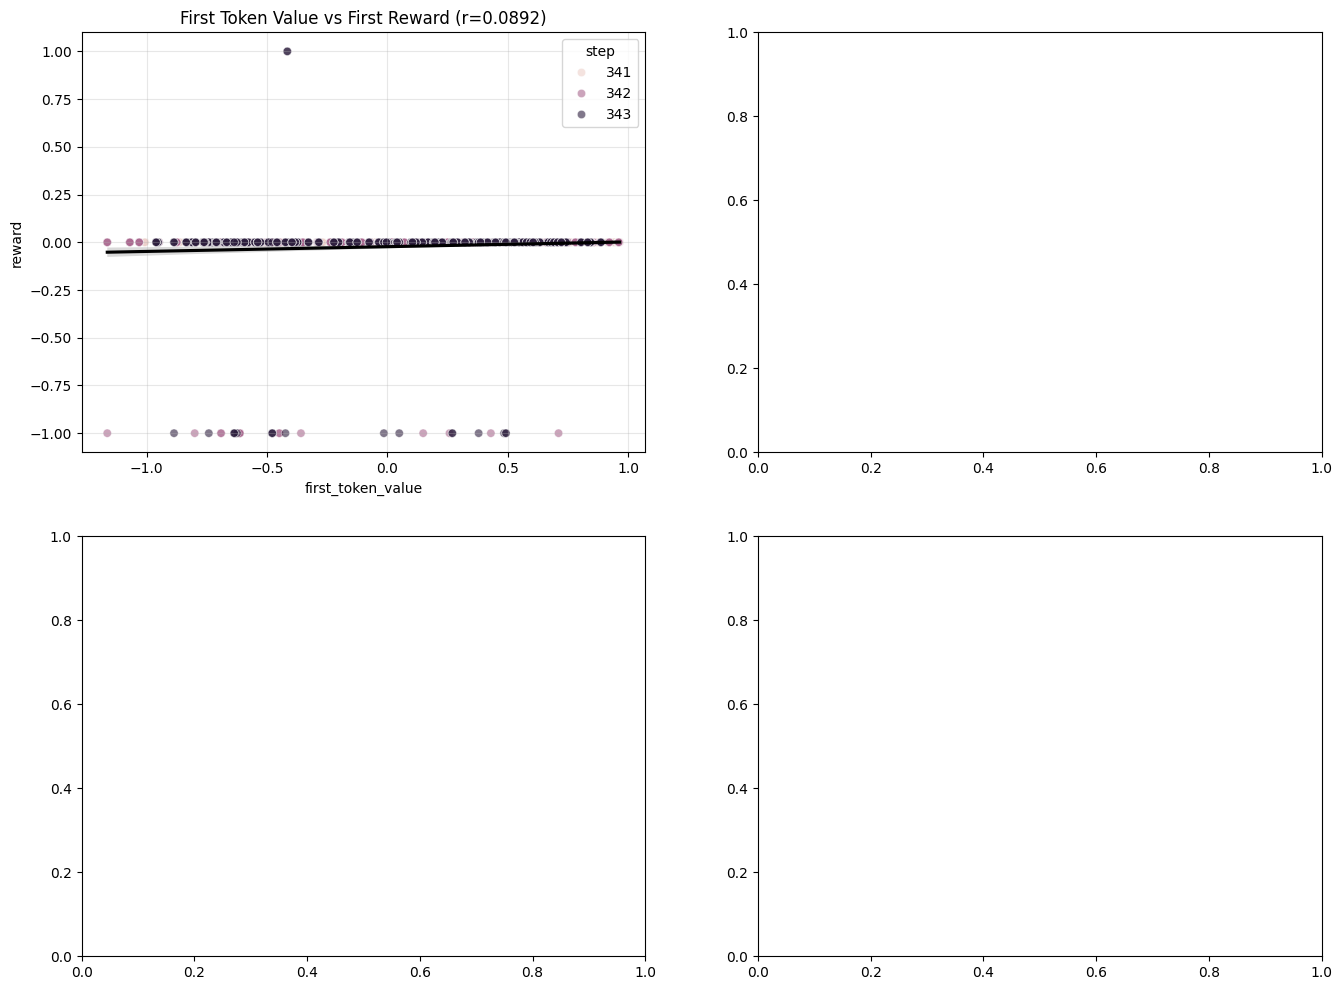

In [182]:
# Plot scatter plots for first token value vs first reward and mean reward
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# First token value vs first reward
sns.scatterplot(x='first_token_value', y='reward', hue='step', data=reward_df, ax=axes[0, 0], alpha=0.6)
sns.regplot(x='first_token_value', y='reward', data=reward_df, scatter=False, ax=axes[0, 0], line_kws={'color': 'black'})
axes[0, 0].set_title(f'First Token Value vs First Reward (r={correlation_matrix.loc["first_token_value", "reward"]:.4f})')
axes[0, 0].grid(True, alpha=0.3)

# First token value vs mean reward
sns.scatterplot(x='first_token_value', y='mean_reward', hue='step', data=reward_df, ax=axes[0, 1], alpha=0.6)
sns.regplot(x='first_token_value', y='mean_reward', data=reward_df, scatter=False, ax=axes[0, 1], line_kws={'color': 'black'})
axes[0, 1].set_title(f'First Token Value vs Mean Reward (r={correlation_matrix.loc["first_token_value", "mean_reward"]:.4f})')
axes[0, 1].grid(True, alpha=0.3)

# Average of first 10 tokens vs first reward
sns.scatterplot(x='first_10_avg', y='reward', hue='step', data=reward_df, ax=axes[1, 0], alpha=0.6)
sns.regplot(x='first_10_avg', y='reward', data=reward_df, scatter=False, ax=axes[1, 0], line_kws={'color': 'black'})
axes[1, 0].set_title(f'First 10 Tokens Avg vs First Reward (r={correlation_matrix.loc["first_10_avg", "reward"]:.4f})')
axes[1, 0].grid(True, alpha=0.3)

# Average of first 10 tokens vs mean reward
sns.scatterplot(x='first_10_avg', y='mean_reward', hue='step', data=reward_df, ax=axes[1, 1], alpha=0.6)
sns.regplot(x='first_10_avg', y='mean_reward', data=reward_df, scatter=False, ax=axes[1, 1], line_kws={'color': 'black'})
axes[1, 1].set_title(f'First 10 Tokens Avg vs Mean Reward (r={correlation_matrix.loc["first_10_avg", "mean_reward"]:.4f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate correlation by step for first token value and mean reward
step_reward_correlations = []

for step in steps:
    step_data = reward_df[reward_df['step'] == step]
    
    pearson_corrs = {}
    spearman_corrs = {}
    
    for token_col in token_cols:
        for reward_col in reward_cols:
            pearson_key = f'{token_col}_vs_{reward_col}_pearson'
            spearman_key = f'{token_col}_vs_{reward_col}_spearman'
            
            pearson_corrs[pearson_key] = step_data[token_col].corr(step_data[reward_col])
            spearman_corrs[spearman_key] = step_data[token_col].corr(step_data[reward_col], method='spearman')
    
    step_reward_correlations.append({
        'step': step,
        **pearson_corrs,
        **spearman_corrs
    })

step_reward_df = pd.DataFrame(step_reward_correlations)

# Print correlations for first token value vs rewards by step
print("Correlation between first token value and rewards by step:")
for step in steps:
    step_row = step_reward_df[step_reward_df['step'] == step].iloc[0]
    print(f"\nStep {step}:")
    for reward_col in reward_cols:
        p_corr = step_row[f'first_token_value_vs_{reward_col}_pearson']
        s_corr = step_row[f'first_token_value_vs_{reward_col}_spearman']
        print(f"  - vs {reward_col}: Pearson = {p_corr:.4f}, Spearman = {s_corr:.4f}")

In [ ]:
# Plot how correlations between token values and rewards evolve across steps
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
token_reward_pairs = [
    ('first_token_value', 'first_reward'),
    ('first_token_value', 'mean_reward'),
    ('first_10_avg', 'first_reward'),
    ('first_10_avg', 'mean_reward')
]

for i, (token_col, reward_col) in enumerate(token_reward_pairs):
    row, col = i // 2, i % 2
    
    # Extract correlation values for this pair across steps
    pearson_key = f'{token_col}_vs_{reward_col}_pearson'
    spearman_key = f'{token_col}_vs_{reward_col}_spearman'
    
    # Plot the correlation trends
    axes[row, col].plot(step_reward_df['step'], step_reward_df[pearson_key], 'o-', label='Pearson', linewidth=2, markersize=10)
    axes[row, col].plot(step_reward_df['step'], step_reward_df[spearman_key], 's-', label='Spearman', linewidth=2, markersize=10)
    
    axes[row, col].set_title(f'Correlation: {token_col} vs {reward_col} Across Steps')
    axes[row, col].set_xlabel('Step')
    axes[row, col].set_ylabel('Correlation Coefficient')
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].legend()
    axes[row, col].set_xticks(steps)

plt.tight_layout()
plt.show()

## Token-by-Token Correlation with Reward

Let's analyze how the correlation with reward changes across token positions.

In [ ]:
# Analyze correlation between individual token positions and rewards
max_tokens_to_analyze = 20  # Analyze up to the first 20 tokens
token_reward_corr = []

for pos in range(max_tokens_to_analyze):
    token_values = []
    first_rewards = []
    mean_rewards = []
    steps = []
    
    for i, (values, rewards) in enumerate(zip(all_values_list, rewards_list)):
        if len(values) > pos and len(rewards) > 0:  # Check if this position exists
            token_values.append(float(values[pos]))
            first_rewards.append(float(rewards[0]))
            mean_rewards.append(float(rewards.mean()))
            steps.append(all_step_info[i])
    
    # Create a DataFrame for this position
    pos_df = pd.DataFrame({
        'token_value': token_values,
        'first_reward': first_rewards,
        'mean_reward': mean_rewards,
        'step': steps
    })
    
    # Calculate overall correlations
    pearson_first = pos_df['token_value'].corr(pos_df['first_reward'])
    pearson_mean = pos_df['token_value'].corr(pos_df['mean_reward'])
    spearman_first = pos_df['token_value'].corr(pos_df['first_reward'], method='spearman')
    spearman_mean = pos_df['token_value'].corr(pos_df['mean_reward'], method='spearman')
    
    # Calculate correlations by step
    step_corrs = {}
    for step in pd.unique(pos_df['step']):
        step_data = pos_df[pos_df['step'] == step]
        step_corrs[f'step_{step}_first_p'] = step_data['token_value'].corr(step_data['first_reward'])
        step_corrs[f'step_{step}_mean_p'] = step_data['token_value'].corr(step_data['mean_reward'])
        step_corrs[f'step_{step}_first_s'] = step_data['token_value'].corr(step_data['first_reward'], method='spearman')
        step_corrs[f'step_{step}_mean_s'] = step_data['token_value'].corr(step_data['mean_reward'], method='spearman')
    
    token_reward_corr.append({
        'position': pos + 1,  # 1-indexed for clarity
        'pearson_first': pearson_first,
        'pearson_mean': pearson_mean,
        'spearman_first': spearman_first,
        'spearman_mean': spearman_mean,
        **step_corrs
    })

token_reward_corr_df = pd.DataFrame(token_reward_corr)
print("Correlation between token positions and rewards:")
print(token_reward_corr_df[['position', 'pearson_first', 'pearson_mean', 'spearman_first', 'spearman_mean']])

In [ ]:
# Plot correlations by token position
plt.figure(figsize=(14, 7))

# Plot overall correlations
plt.plot(token_reward_corr_df['position'], token_reward_corr_df['pearson_first'], 
         'o-', linewidth=2, label='Token Value vs First Reward (Pearson)', color='blue', markersize=8)
plt.plot(token_reward_corr_df['position'], token_reward_corr_df['pearson_mean'], 
         's-', linewidth=2, label='Token Value vs Mean Reward (Pearson)', color='green', markersize=8)
plt.plot(token_reward_corr_df['position'], token_reward_corr_df['spearman_first'], 
         '^-', linewidth=2, label='Token Value vs First Reward (Spearman)', color='orange', markersize=8)
plt.plot(token_reward_corr_df['position'], token_reward_corr_df['spearman_mean'], 
         'D-', linewidth=2, label='Token Value vs Mean Reward (Spearman)', color='red', markersize=8)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.title('Correlation between Token Value and Reward by Token Position')
plt.xlabel('Token Position')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(token_reward_corr_df['position'])
plt.tight_layout()
plt.show()

## Value vs Reward Correlation Compared to Response Length

Let's examine how the correlations between token values and rewards compare to the correlations with response length.

In [ ]:
# Combine the correlation results for comparison
comparison_data = {
    'Token Position': list(range(1, max_tokens_to_analyze + 1)),
    'vs Response Length (Pearson)': position_corr_df['overall_corr'],
    'vs Response Length (Spearman)': position_spearman_df['overall_corr'],
    'vs First Reward (Pearson)': token_reward_corr_df['pearson_first'],
    'vs First Reward (Spearman)': token_reward_corr_df['spearman_first'],
    'vs Mean Reward (Pearson)': token_reward_corr_df['pearson_mean'],
    'vs Mean Reward (Spearman)': token_reward_corr_df['spearman_mean']
}

comparison_df = pd.DataFrame(comparison_data)

# Plot the comparison
plt.figure(figsize=(15, 8))

# Plot correlations with response length
plt.plot(comparison_df['Token Position'], comparison_df['vs Response Length (Pearson)'], 
         'o-', linewidth=2, label='vs Response Length (Pearson)', markersize=8)
plt.plot(comparison_df['Token Position'], comparison_df['vs Response Length (Spearman)'], 
         's-', linewidth=2, label='vs Response Length (Spearman)', markersize=8)

# Plot correlations with rewards
plt.plot(comparison_df['Token Position'], comparison_df['vs First Reward (Pearson)'], 
         '^-', linewidth=2, label='vs First Reward (Pearson)', markersize=8)
plt.plot(comparison_df['Token Position'], comparison_df['vs Mean Reward (Pearson)'], 
         'D-', linewidth=2, label='vs Mean Reward (Pearson)', markersize=8)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.title('Comparison of Correlations Across Token Positions')
plt.xlabel('Token Position')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(comparison_df['Token Position'])
plt.tight_layout()
plt.show()

## Coefficient of Determination for Token-Reward Relationships

Calculate the r² values to understand the proportion of variance in reward that can be explained by token values.

In [ ]:
# Calculate r² values for token-reward relationships
reward_r_squared = pd.DataFrame({
    'Metric': token_cols,
    'vs_first_reward_r': [correlation_matrix.loc[col, 'first_reward'] for col in token_cols],
    'vs_first_reward_r²': [correlation_matrix.loc[col, 'first_reward']**2 for col in token_cols],
    'vs_mean_reward_r': [correlation_matrix.loc[col, 'mean_reward'] for col in token_cols],
    'vs_mean_reward_r²': [correlation_matrix.loc[col, 'mean_reward']**2 for col in token_cols],
    'vs_response_length_r': [reward_df[col].corr(reward_df['response_length']) for col in token_cols],
    'vs_response_length_r²': [reward_df[col].corr(reward_df['response_length'])**2 for col in token_cols]
})

print("Coefficient of determination (r²) for token-reward relationships:")
print(reward_r_squared)

# Plot r² values
plt.figure(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(token_cols))

plt.bar(x - bar_width, reward_r_squared['vs_first_reward_r²'], bar_width, label='vs First Reward')
plt.bar(x, reward_r_squared['vs_mean_reward_r²'], bar_width, label='vs Mean Reward')
plt.bar(x + bar_width, reward_r_squared['vs_response_length_r²'], bar_width, label='vs Response Length')

plt.xlabel('Token Value Metric')
plt.ylabel('r² (Variance Explained)')
plt.title('Variance in Reward and Response Length Explained by Token Values')
plt.xticks(x, token_cols)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Reward vs Response Length

Finally, let's examine the relationship between rewards and response length directly.

In [ ]:
# Calculate correlations between reward metrics and response length
reward_length_corr = {
    'first_reward_vs_length_pearson': reward_df['first_reward'].corr(reward_df['response_length']),
    'mean_reward_vs_length_pearson': reward_df['mean_reward'].corr(reward_df['response_length']),
    'first_reward_vs_length_spearman': reward_df['first_reward'].corr(reward_df['response_length'], method='spearman'),
    'mean_reward_vs_length_spearman': reward_df['mean_reward'].corr(reward_df['response_length'], method='spearman')
}

print("Correlation between reward and response length:")
for key, value in reward_length_corr.items():
    print(f"{key}: {value:.4f}")

# Plot scatter plots for reward vs response length
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First reward vs response length
sns.scatterplot(x='first_reward', y='response_length', hue='step', data=reward_df, ax=axes[0], alpha=0.6)
sns.regplot(x='first_reward', y='response_length', data=reward_df, scatter=False, ax=axes[0], line_kws={'color': 'black'})
axes[0].set_title(f'First Reward vs Response Length (r={reward_length_corr["first_reward_vs_length_pearson"]:.4f})')
axes[0].set_xlabel('First Reward Value')
axes[0].set_ylabel('Response Length')
axes[0].grid(True, alpha=0.3)

# Mean reward vs response length
sns.scatterplot(x='mean_reward', y='response_length', hue='step', data=reward_df, ax=axes[1], alpha=0.6)
sns.regplot(x='mean_reward', y='response_length', data=reward_df, scatter=False, ax=axes[1], line_kws={'color': 'black'})
axes[1].set_title(f'Mean Reward vs Response Length (r={reward_length_corr["mean_reward_vs_length_pearson"]:.4f})')
axes[1].set_xlabel('Mean Reward Value')
axes[1].set_ylabel('Response Length')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()